# Tahap 2: Pemrograman Model JST Backpropagation

Pada tahap ini, kita membangun model JST untuk memprediksi harga beras menggunakan algoritma Backpropagation
1. Normalisasi data (MinMaxScaler).
2. Pemisahan data training dan testing.
3. Inisialisasi dan training model JST.
4. Hyperparameter tuning untuk optimalisasi.

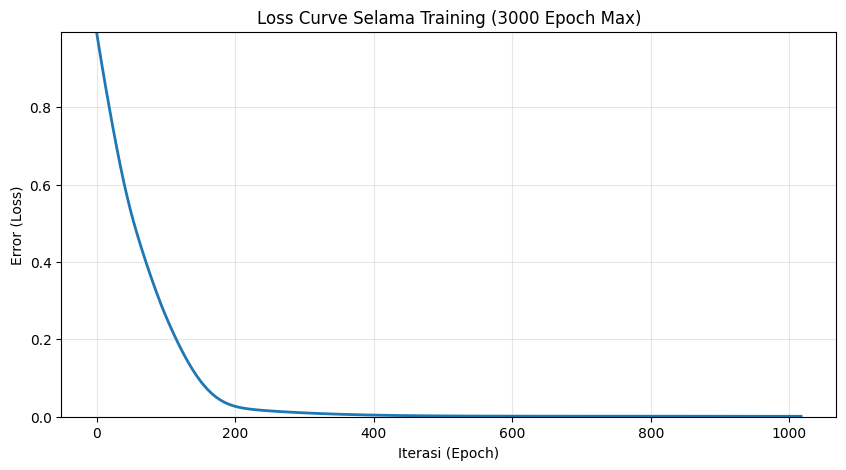

Total epoch yang dijalankan: 1018
Loss akhir: 0.001115


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Load Data Preprocessed (Scaled)
df = pd.read_csv('beras_scaled.csv')

# Menentukan Fitur (X) dan Target (y) dari data yang sudah di-scale
X_scaled = df[['lag_1_scaled', 'lag_2_scaled']].values
y_scaled = df['jumlah_scaled'].values.reshape(-1, 1)

# 2. Split Data (Training & Testing)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42, shuffle=False)

# 3. Inisialisasi Model JST Backpropagation
model = MLPRegressor(
    hidden_layer_sizes=(12, 8), 
    activation='relu', 
    solver='adam', 
    max_iter=3000, 
    learning_rate_init=0.001, 
    learning_rate='adaptive',
    tol=1e-6,
    n_iter_no_change=200,
    early_stopping=False,
    random_state=42,
    verbose=False
)

# 5. Proses Training
model.fit(X_train, y_train.ravel())

# 6. Visualisasi Loss Curve (Proses Belajar)
plt.figure(figsize=(10,5))
plt.plot(model.loss_curve_, linewidth=2)
plt.title('Loss Curve Selama Training (3000 Epoch Max)')
plt.xlabel('Iterasi (Epoch)')
plt.ylabel('Error (Loss)')
plt.grid(True, alpha=0.3)
plt.ylim(0, max(model.loss_curve_[:10]))  
plt.show()

print(f"Total epoch yang dijalankan: {model.n_iter_}")
print(f"Loss akhir: {model.loss_:.6f}")

# Simpan data loss curve untuk dashboard
df_loss = pd.DataFrame({'loss': model.loss_curve_})
df_loss.to_csv('loss_curve.csv', index=False)


### Pengujian & Hyperparameter Tuning

RMSE: 114.57
MAE : 92.85
MAPE: 0.75%


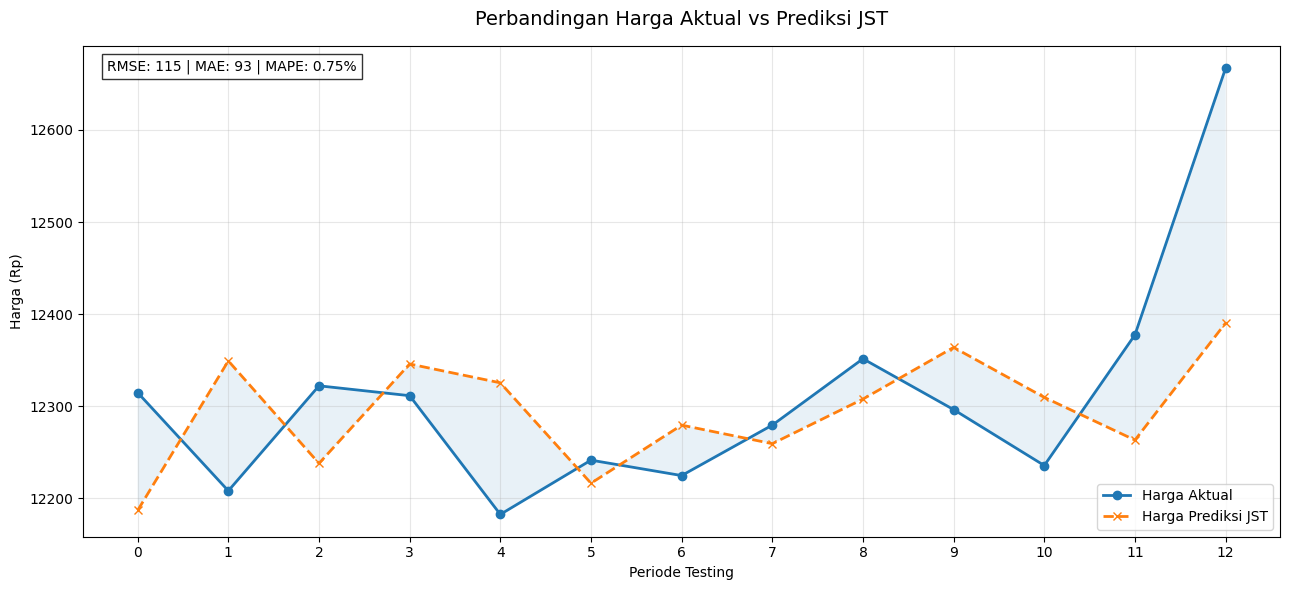

In [10]:
from sklearn.metrics import mean_absolute_error

# Hitung metrik tambahan
mae = mean_absolute_error(y_actual, y_pred)
mape = np.mean(np.abs((y_actual - y_pred) / y_actual)) * 100

print(f"RMSE: {rmse:.2f}")
print(f"MAE : {mae:.2f}")
print(f"MAPE: {mape:.2f}%")

plt.figure(figsize=(13,6))
x_axis = np.arange(len(y_actual))

plt.plot(x_axis, y_actual, label='Harga Aktual', marker='o', linewidth=2)
plt.plot(x_axis, y_pred, label='Harga Prediksi JST', marker='x', linewidth=2, linestyle='--')
plt.fill_between(x_axis, y_actual.flatten(), y_pred.flatten(), alpha=0.1)  # area error

plt.title('Perbandingan Harga Aktual vs Prediksi JST', fontsize=14, pad=15)
plt.ylabel('Harga (Rp)')
plt.xlabel('Periode Testing')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(x_axis)

plt.text(0.02, 0.95, f'RMSE: {rmse:.0f} | MAE: {mae:.0f} | MAPE: {mape:.2f}%', 
         transform=plt.gca().transAxes, bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()